# Library

In [1]:
library(readr)  #Membaca data
library(dplyr)  #Data processing
library(DT)     #Menampilkan tabel agar mudah dilihat di browser


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
umkm_data <- read_csv("/kaggle/input/umkm-2/UMKM 2 - Sheet1.csv")
head(umkm_data)

Rows: 30 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Nama UMKM, 1. Bagaimana  kepuasaan anda terhadap penggunaan e-Comm...
dbl (10): E-Commerce memudahkan UMKM dalam pemasaran produk, E-Commerce memb...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Nama UMKM,1. Bagaimana kepuasaan anda terhadap penggunaan e-Commerce secara keseluruhan?,E-Commerce memudahkan UMKM dalam pemasaran produk,E-Commerce membantu UMKM menjangkau pasar lebih luas,E-Commerce mengurangi hambatan masuk pasar bagi UMKM,E-Commerce mengurangi biaya pemasaran,"E-Commerce memungkinkan perubahan model bisnis (seller, reseller, dropship)",Digitalisasi memudahkan UMKM dalam berinovasi,Digitalisasi memudahkan UMKM untuk melakukan kolaborasi dengan usaha/perusahaan lain,Digitalisasi memberikan UMKM kesempatan lebih luas dalam mengembangkan usaha,Digitalisasi menurunkan biaya operasional,Digitalisasi meningkatkan persaingan usaha
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Crisbar ( Crispy Bakar),Sangat Puas,5,5,3,3,4,5,5,5,4,4
clematis coffe,Puas,4,4,3,4,4,5,4,4,3,5
Yourtea,Puas,4,4,4,4,4,4,4,4,3,4
Chick N Tea,Puas,5,5,5,4,5,5,5,5,4,4
WARKOP BALEBAK MANDIRI 2,Puas,5,5,4,5,4,5,4,5,4,5
Kedai Jawir,Netral,4,4,4,2,4,3,4,5,3,4


In [3]:
df <- umkm_data

In [ ]:
df

In [5]:
df_feature <- df[,3:12]

In [6]:
df_feature

E-Commerce memudahkan UMKM dalam pemasaran produk,E-Commerce membantu UMKM menjangkau pasar lebih luas,E-Commerce mengurangi hambatan masuk pasar bagi UMKM,E-Commerce mengurangi biaya pemasaran,"E-Commerce memungkinkan perubahan model bisnis (seller, reseller, dropship)",Digitalisasi memudahkan UMKM dalam berinovasi,Digitalisasi memudahkan UMKM untuk melakukan kolaborasi dengan usaha/perusahaan lain,Digitalisasi memberikan UMKM kesempatan lebih luas dalam mengembangkan usaha,Digitalisasi menurunkan biaya operasional,Digitalisasi meningkatkan persaingan usaha
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5,5,3,3,4,5,5,5,4,4
4,4,3,4,4,5,4,4,3,5
4,4,4,4,4,4,4,4,3,4
5,5,5,4,5,5,5,5,4,4
5,5,4,5,4,5,4,5,4,5
4,4,4,2,4,3,4,5,3,4
5,5,5,5,5,5,5,5,5,5
4,4,4,4,4,4,4,4,2,4
3,3,3,3,3,5,3,5,3,3


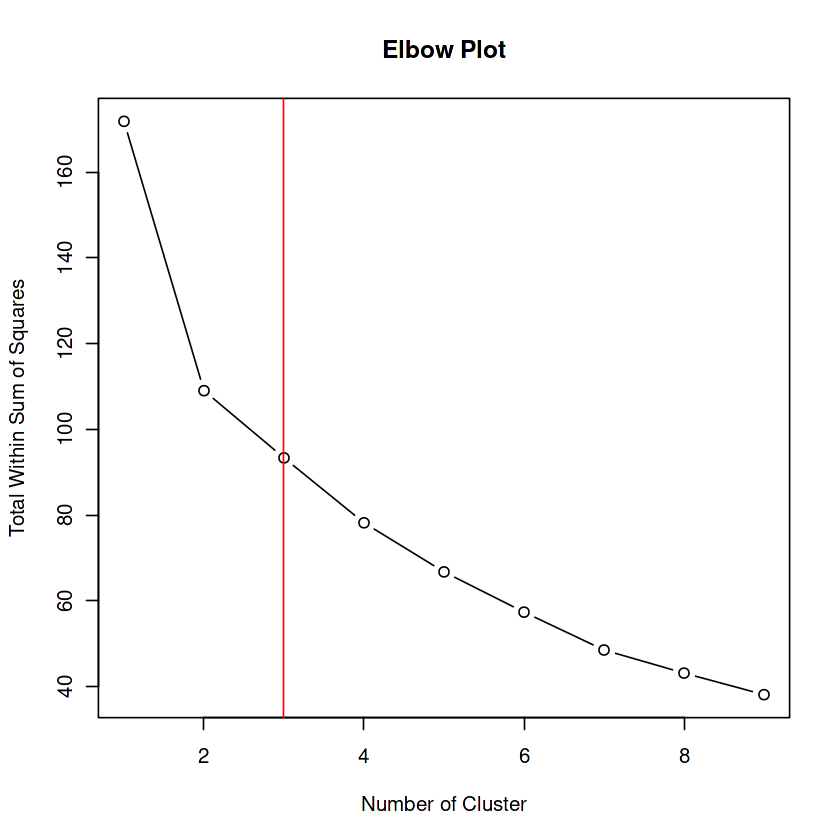

In [8]:
jumlah_klaster <- c(1:9)  #Vektor yang berisikan jumlah klaster yang ingin dilihat nilai dari total within-cluster sum of squares
within_ss <- c()  #Vektor kosong yang akan diisi nilai total within-cluster sum of squares
for (i in jumlah_klaster) {
  within_ss <- c(within_ss, kmeans(x = df_feature, centers = i, nstart = 25)$tot.withinss)
}

plot(x = jumlah_klaster, y = within_ss, type = "b", xlab = "Number of Cluster",
     ylab = "Total Within Sum of Squares", main = "Elbow Plot")
abline(v = 3, col = 'red')

# Analisis CLaster

In [12]:
set.seed(123)
kmeans_clustering <- kmeans(x = df_feature, centers = 3, nstart = 25)  #parameter nstart digunakan untuk memberitahu fungsi berapa kali inisiasi centroid awal (secara acak) yang akan dibentuk dan centers digunakan untuk memberitahu fungsi berapa jumlah klaster yang akan dibentuk.
kmeans_clustering

K-means clustering with 3 clusters of sizes 15, 7, 8

Cluster means:
  E-Commerce memudahkan UMKM dalam pemasaran produk
1                                          4.933333
2                                          3.000000
3                                          4.250000
  E-Commerce membantu UMKM menjangkau pasar lebih luas
1                                             4.866667
2                                             3.285714
3                                             4.375000
  E-Commerce mengurangi hambatan masuk pasar bagi UMKM
1                                             4.066667
2                                             3.142857
3                                             3.750000
  E-Commerce mengurangi biaya pemasaran
1                              4.400000
2                              3.285714
3                              3.250000
  E-Commerce memungkinkan perubahan model bisnis (seller, reseller, dropship)
1                                            

In [13]:
library(factoextra)

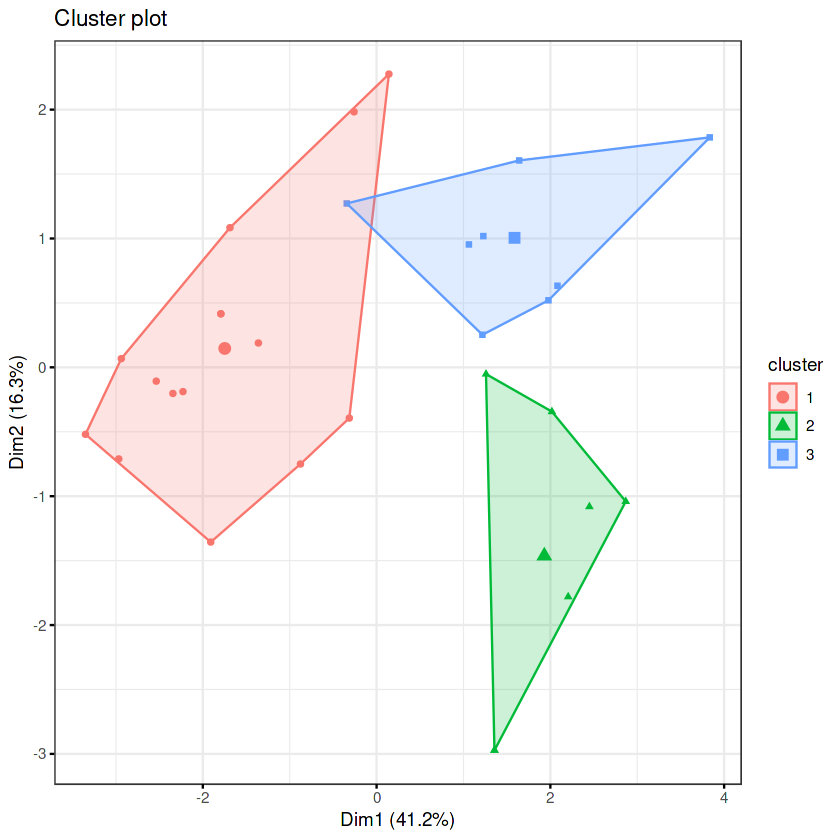

In [14]:
fviz_cluster(kmeans_clustering, data = df_feature, 
             geom = "point",
             ellipse.type = "convex", 
             ggtheme = theme_bw()
             )

In [ ]:
df = df %>%
  mutate (Klaster = kmeans_clustering$cluster) %>%
  select("Nama UMKM", Klaster) %>%
  arrange(Klaster)

In [15]:
df_klaster = df %>%
  mutate (Klaster = kmeans_clustering$cluster)

In [16]:
df_klaster

Nama UMKM,1. Bagaimana kepuasaan anda terhadap penggunaan e-Commerce secara keseluruhan?,E-Commerce memudahkan UMKM dalam pemasaran produk,E-Commerce membantu UMKM menjangkau pasar lebih luas,E-Commerce mengurangi hambatan masuk pasar bagi UMKM,E-Commerce mengurangi biaya pemasaran,"E-Commerce memungkinkan perubahan model bisnis (seller, reseller, dropship)",Digitalisasi memudahkan UMKM dalam berinovasi,Digitalisasi memudahkan UMKM untuk melakukan kolaborasi dengan usaha/perusahaan lain,Digitalisasi memberikan UMKM kesempatan lebih luas dalam mengembangkan usaha,Digitalisasi menurunkan biaya operasional,Digitalisasi meningkatkan persaingan usaha,Klaster
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Crisbar ( Crispy Bakar),Sangat Puas,5,5,3,3,4,5,5,5,4,4,1
clematis coffe,Puas,4,4,3,4,4,5,4,4,3,5,3
Yourtea,Puas,4,4,4,4,4,4,4,4,3,4,3
Chick N Tea,Puas,5,5,5,4,5,5,5,5,4,4,1
WARKOP BALEBAK MANDIRI 2,Puas,5,5,4,5,4,5,4,5,4,5,1
Kedai Jawir,Netral,4,4,4,2,4,3,4,5,3,4,3
Mimici,Sangat Puas,5,5,5,5,5,5,5,5,5,5,1
Warkop HS 1 Babakan Lio,Netral,4,4,4,4,4,4,4,4,2,4,3
Warkop Portal,Netral,3,3,3,3,3,5,3,5,3,3,2


In [17]:
write.csv(df_klaster, file = "data_clustered.csv", row.names = FALSE)